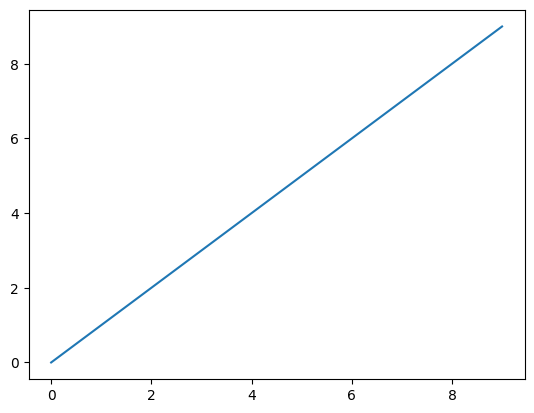

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.plot(np.arange(10))


In [2]:
from pandas import DataFrame, Series
import pandas as pd

#1차원 배열
myCampus = Series([100, 200, 300, 400,500])
myCampus[2]

#셀단위 실행 : shift + enter


                  

np.int64(300)

In [8]:
#파이썬 딕셔너리를 초기화
data = {"foreigners": [100, 200, 300, 400, 500]
        , "sratio": [50, 60, 70, 80, 90]
        , "org" : [1,2,3,4,5]
        , "sprice": [1000, 2000, 3000, 4000, 5000]
        , "private": [10, 20, 30, 40, 50]
      }

frame1 = DataFrame(data)
frame1



,foreigners,sratio,org,sprice,private
0,100,50,1,1000,10
1,200,60,2,2000,20
2,300,70,3,3000,30
3,400,80,4,4000,40
4,500,90,5,5000,50


In [9]:
frame1.info()


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   foreigners  5 non-null      int64
 1   sratio      5 non-null      int64
 2   org         5 non-null      int64
 3   sprice      5 non-null      int64
 4   private     5 non-null      int64
dtypes: int64(5)
memory usage: 332.0 bytes


In [19]:
frame2 = DataFrame(data
                   ,index=["2026-09-01", "2026-09-02", "2026-09-03", "2026-09-04", "2026-09-05"]
                   ,columns=["private", "foreigners", "sratio", "org", "sprice"]
                   )
frame2["org"]


2026-09-01    1
2026-09-02    2
2026-09-03    3
2026-09-04    4
2026-09-05    5
Name: org, dtype: int64

# 타이타닉 생존 데이터 분석

공개된 타이타닉호 생존 데이터셋을 불러와 남성과 여성의 생존율을 비교합니다. 차트 출력 전에 시스템에 설치된 한글 폰트를 찾아 `matplotlib`에 등록합니다.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 공개된 타이타닉 생존 데이터셋 불러오기
data_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(data_url)

# 분석에 필요한 열만 확인하고 결측치를 제거
analysis_data = titanic[["sex", "survived"]].dropna().copy()
analysis_data["성별"] = analysis_data["sex"].map({"male": "남성", "female": "여성"})

# 성별 생존율(%) 계산
survival_rate = (
    analysis_data.groupby("성별", sort=False)["survived"]
    .mean()
    .mul(100)
    .reindex(["남성", "여성"])
)

survival_rate.round(2)

성별
남성    18.89
여성    74.20
Name: survived, dtype: float64

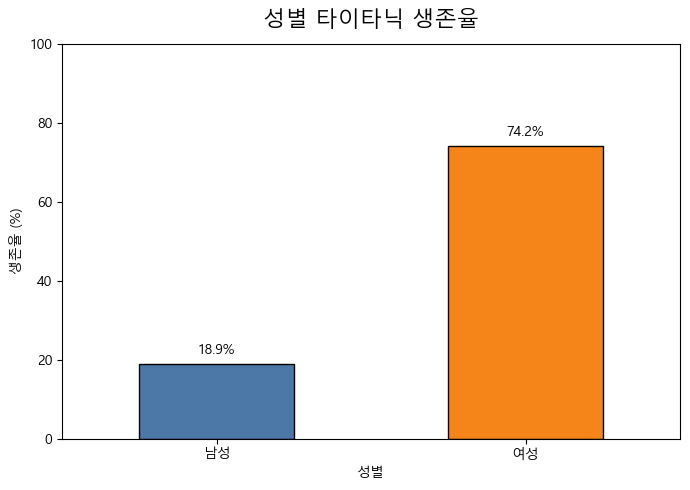

적용된 한글 폰트: Malgun Gothic


In [5]:
# 한글 폰트 설정: 운영체제에 설치된 폰트를 순서대로 탐색
font_candidates = [
    "Malgun Gothic",       # Windows
    "AppleGothic",         # macOS
    "NanumGothic",         # Linux 또는 별도 설치 폰트
    "Noto Sans CJK KR",
]

for font_name in font_candidates:
    try:
        font_path = font_manager.findfont(
            font_name,
            fallback_to_default=False,
        )
        rcParams["font.family"] = font_name
        break
    except (ValueError, OSError):
        continue
else:
    raise RuntimeError(
        "한글 폰트를 찾지 못했습니다. Malgun Gothic 또는 NanumGothic을 설치해 주세요."
    )

rcParams["axes.unicode_minus"] = False

ax = survival_rate.plot(
    kind="bar",
    figsize=(7, 5),
    color=["#4C78A8", "#F58518"],
    edgecolor="black",
)
ax.set_title("성별 타이타닉 생존율", fontsize=16, pad=12)
ax.set_xlabel("성별")
ax.set_ylabel("생존율 (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

for bar, value in zip(ax.patches, survival_rate):
    ax.annotate(
        f"{value:.1f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

print(f"적용된 한글 폰트: {rcParams['font.family'][0]}")